In [1]:
!pip install ultralytics
!pip install scipy
!pip install roboflow
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.8 MB/s eta 0:00:00
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 455, in run
    installed = install_given_reqs(
                ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/req/__init__.py", line 70, in install_given_reqs
    requirement.install(
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/req/req_install.py", line 851, in install
    install_wheel(
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/install/wheel.py", line 726, in

In [2]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from roboflow import Roboflow
rf = Roboflow(api_key="EnyYEAry3FTybph77K2I")
project = rf.workspace("yolov8car").project("car-and-pedestrian-qbzyx")
version = project.version(1)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to car-and-pedestrian--1 in yolo26:: 100%|██████████| 412/412 [00:00<00:00, 8577.61it/s]


In [4]:
model = YOLO("yolo26n.pt")

In [7]:
from pathlib import Path

data_yaml = Path("/content/car-and-pedestrian--1/data.yaml")

print(data_yaml.exists())

True


In [8]:
results = model.train(
    data = data_yaml,
    epochs=100,
    imgsz=640,
    batch=8
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/car-and-pedestrian--1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100,

In [9]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,616 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 981.2±101.4 MB/s, size: 43.2 KB)
val: Scanning /content/car-and-pedestrian--1/valid/labels.cache... 40 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40 11.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.9it/s 1.6s
                   all         40         55      0.893      0.818      0.831      0.626
                   car         32         44      0.966      0.727      0.873      0.668
            pedestrian          8         11       0.82      0.909      0.789      0.584
Speed: 6.7ms preprocess, 15.6ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])

In [11]:
results = model.predict(
    source= "/content/car-and-pedestrian--1/test/images",
    conf=0.25,
    save=True
)


image 1/20 /content/car-and-pedestrian--1/test/images/-1058CFB8-55AA-4270-937C-FAB55C49F17A-png_jpg.rf.a1061151a5cd92acdb232bf3289d0f08.jpg: 640x640 2 cars, 11.7ms
image 2/20 /content/car-and-pedestrian--1/test/images/-1EE5CA55-C89F-4985-8D4E-A56DBD1A1E96-png_jpg.rf.f83419a3fab3065cfac77d0011913c31.jpg: 640x640 2 cars, 9.1ms
image 3/20 /content/car-and-pedestrian--1/test/images/-26D423C9-C9F8-4CA3-B49E-3664225FB20C-png_jpg.rf.e30382c31215dcc537635640285a49ab.jpg: 640x640 2 cars, 3 pedestrians, 9.1ms
image 4/20 /content/car-and-pedestrian--1/test/images/-375329E9-678F-4B48-AED2-472A7ED60D19-png_jpg.rf.23d4cc9801f6f8d3a252d8fc0877c039.jpg: 640x640 1 car, 9.3ms
image 5/20 /content/car-and-pedestrian--1/test/images/-3D578705-6794-4049-BF6D-A828FC4F0722-png_jpg.rf.edfceb0756d2a454d6278261baba9e1e.jpg: 640x640 1 car, 11.8ms
image 6/20 /content/car-and-pedestrian--1/test/images/-44EED5AD-F010-4649-819C-9091185CA9AD-png_jpg.rf.ea30eb39a05721b713551641b99d1ca8.jpg: 640x640 1 car, 9.1ms
image 7

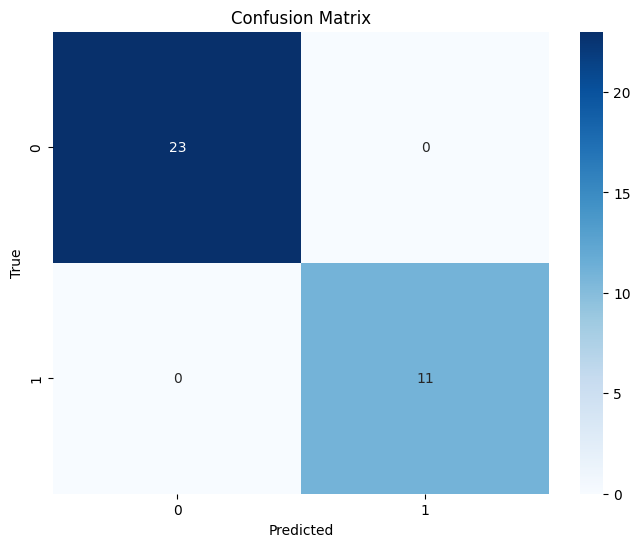

In [12]:
y_true = []
y_pred = []
for result in results:
  pred = result.boxes.cls.cpu().numpy()
  true = result.boxes.cls.cpu().numpy()

  y_pred.extend(pred)
  y_true.extend(true)

cm = confusion_matrix(y_true, y_pred)


plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [13]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        23
         1.0       1.00      1.00      1.00        11

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34

